# GoEmotions manifold plots

This notebook creates the requested plots from the outputs of `goemotions_embed_pipeline.py` and `goemotions_manifold_analysis.py`.

Expected local files:

- `D:/pyprojects/m4r/data/goemotions/manifold_outputs/embeddings.npy`
- `D:/pyprojects/m4r/data/goemotions/manifold_outputs/metadata.csv`
- `D:/pyprojects/m4r/data/goemotions/emotion_label_vad_starter.csv`

Outputs are saved to:

- `D:/pyprojects/m4r/new_plots`

Notes:

- For the manifold scatter, `DISTANCE_METHOD = "cosine"` computes cosine distance, i.e. `1 - cosine similarity`, because the scatter compares distances.
- `DISTANCE_METHOD = "knn_geodesic"` computes shortest-path distances on a symmetric KNN graph.
- `GROUND_TRUTH_SPACE` can be one of `"valence"`, `"arousal"`, `"dominance"`, `"VA"`, or `"VAD"`.

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors

import plotly.graph_objects as go
import plotly.express as px

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
})

## Configuration

Change only this cell for paths or distance choices. The default assumes the same folder structure used by the scripts.

In [2]:
DATA_DIR = Path(r"D:\pyprojects\m4r\data\goemotions")
MANIFOLD_OUT_DIR = DATA_DIR / "manifold_outputs"
ANALYSIS_DIR = MANIFOLD_OUT_DIR / "analysis"
OUT_DIR = Path(r"D:\pyprojects\m4r\new_plots")

EMBEDDINGS_PATH = MANIFOLD_OUT_DIR / "embeddings.npy"
METADATA_PATH = MANIFOLD_OUT_DIR / "metadata.csv"
VAD_CSV = DATA_DIR / "emotion_label_vad_starter.csv"

# Plot 2 choices.
# DISTANCE_METHOD: "cosine" or "knn_geodesic"
# GROUND_TRUTH_SPACE: "valence", "arousal", "dominance", "VA", or "VAD"
DISTANCE_METHOD = "cosine"
GROUND_TRUTH_SPACE = "VAD"

# Used only when DISTANCE_METHOD = "knn_geodesic".
# KNN_K = "auto" uses the smallest k that makes the graph connected.
KNN_K = "auto"
KNN_METRIC = "angular"      # "angular", "cosine", or "euclidean"
GEODESIC_PCA_DIMS = 10       # set to 0 to use raw centroid embeddings
K_MAX = 100

# Plot 3 choices.
FOCUS_LABELS = ["fear", "caring", "gratitude", "love"]
PCA_3D_FIT_SCOPE = "global"  # "global" fits PCA on all comments; "selected" fits only selected labels
MAX_3D_PER_LABEL = None      # set to an int, e.g. 500, if Plotly gets slow
SEED = 42

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Saving plots to: {OUT_DIR}")

Saving plots to: D:\pyprojects\m4r\new_plots


## Helper functions

In [3]:
VAD_SPACES = {
    "VAD": ["valence", "arousal", "dominance"],
    "VA": ["valence", "arousal"],
    "valence": ["valence"],
    "arousal": ["arousal"],
    "dominance": ["dominance"],
}


def load_embeddings(path: Path) -> np.ndarray:
    if not path.exists():
        raise FileNotFoundError(f"Missing embeddings file: {path}")
    if path.suffix.lower() == ".npy":
        return np.load(path)
    return pd.read_csv(path, header=None).values


def load_vad(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing VAD CSV: {path}")
    vad = pd.read_csv(path)
    required = {"label_name", "valence", "arousal", "dominance"}
    missing = required - set(vad.columns)
    if missing:
        raise ValueError(f"VAD CSV missing required columns: {sorted(missing)}")
    vad = vad.copy()
    vad["label_name"] = vad["label_name"].astype(str)
    for col in ["valence", "arousal", "dominance"]:
        vad[col] = pd.to_numeric(vad[col], errors="coerce")
    if vad[["valence", "arousal", "dominance"]].isna().any().any():
        bad = vad[vad[["valence", "arousal", "dominance"]].isna().any(axis=1)]
        raise ValueError("Some VAD rows contain missing or non-numeric values:\n" + bad.to_string(index=False))
    return vad


def attach_vad(labels: pd.DataFrame, vad_df: pd.DataFrame) -> pd.DataFrame:
    out = labels.merge(
        vad_df[["label_name", "valence", "arousal", "dominance"]],
        on="label_name",
        how="left",
    )
    if out[["valence", "arousal", "dominance"]].isna().any().any():
        missing = sorted(out.loc[out["valence"].isna(), "label_name"].unique())
        raise ValueError(f"Missing VAD rows for labels: {missing}")
    return out


def make_centroids(X: np.ndarray, metadata: pd.DataFrame, vad_df: pd.DataFrame) -> tuple[np.ndarray, pd.DataFrame]:
    if len(X) != len(metadata):
        raise ValueError(f"Embeddings and metadata length differ: {len(X)} vs {len(metadata)}")
    work = metadata[["label_idx", "label_name"]].copy()
    work["_row"] = np.arange(len(work))

    rows = []
    centroids = []
    for label_name, group in work.groupby("label_name", sort=True):
        idx = group["_row"].to_numpy()
        centroids.append(X[idx].mean(axis=0))
        rows.append({
            "label_name": label_name,
            "label_idx": int(group["label_idx"].iloc[0]),
            "n_comments": int(len(group)),
        })

    centroid_meta = attach_vad(pd.DataFrame(rows), vad_df)
    return np.vstack(centroids), centroid_meta


def vad_distance(vad_values: np.ndarray, space: str) -> np.ndarray:
    if space not in VAD_SPACES:
        raise ValueError(f"Unknown ground truth space {space!r}. Use one of {sorted(VAD_SPACES)}")
    col_idx = [{"valence": 0, "arousal": 1, "dominance": 2}[c] for c in VAD_SPACES[space]]
    return pairwise_distances(vad_values[:, col_idx], metric="euclidean")


def upper_triangle_frame(D_x: np.ndarray, D_y: np.ndarray, labels: list[str], x_name: str, y_name: str) -> pd.DataFrame:
    iu = np.triu_indices(D_x.shape[0], k=1)
    return pd.DataFrame({
        "label_i": [labels[i] for i in iu[0]],
        "label_j": [labels[j] for j in iu[1]],
        x_name: D_x[iu],
        y_name: D_y[iu],
    })


def angular_pairwise(X: np.ndarray) -> np.ndarray:
    Xn = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
    sims = np.clip(Xn @ Xn.T, -1.0, 1.0)
    return np.arccos(sims)


def build_symmetric_knn_graph(X: np.ndarray, k: int, metric: str) -> csr_matrix:
    n = X.shape[0]
    if k >= n:
        raise ValueError(f"k must be smaller than number of samples. Got k={k}, n={n}")

    if metric == "angular":
        Xn = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
        nbrs = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
        nbrs.fit(Xn)
        _, indices = nbrs.kneighbors(Xn)
        indices = indices[:, 1:]
        rows = np.repeat(np.arange(n), k)
        cols = indices.ravel()
        sims = np.sum(Xn[rows] * Xn[cols], axis=1)
        vals = np.arccos(np.clip(sims, -1.0, 1.0))
    else:
        nbrs = NearestNeighbors(n_neighbors=k + 1, metric=metric)
        nbrs.fit(X)
        distances, indices = nbrs.kneighbors(X)
        distances = distances[:, 1:]
        indices = indices[:, 1:]
        rows = np.repeat(np.arange(n), k)
        cols = indices.ravel()
        vals = distances.ravel()

    G = csr_matrix((vals, (rows, cols)), shape=(n, n))
    return G.maximum(G.T)


def connected_k(X: np.ndarray, metric: str, k_max: int) -> tuple[int, csr_matrix]:
    upper = min(k_max, X.shape[0] - 1)
    for k in range(1, upper + 1):
        G = build_symmetric_knn_graph(X, k=k, metric=metric)
        n_components, _ = connected_components(G, directed=False)
        if n_components == 1:
            return k, G
    raise ValueError(f"Graph did not become connected up to k={upper}")


def geodesic_distance(X: np.ndarray, k_value: str | int = "auto", metric: str = "angular", k_max: int = 100) -> tuple[np.ndarray, int, int]:
    if k_value == "auto":
        actual_k, G = connected_k(X, metric=metric, k_max=k_max)
        n_components = 1
    else:
        actual_k = int(k_value)
        G = build_symmetric_knn_graph(X, k=actual_k, metric=metric)
        n_components, _ = connected_components(G, directed=False)
    D = dijkstra(csgraph=G, directed=False, return_predecessors=False)
    return D, actual_k, int(n_components)


def centroid_manifold_distance(centroid_X: np.ndarray) -> tuple[np.ndarray, str]:
    method = DISTANCE_METHOD.lower().strip()
    if method == "cosine":
        D = pairwise_distances(centroid_X, metric="cosine")
        return D, "Cosine distance (1 - cosine similarity)"
    if method == "knn_geodesic":
        if GEODESIC_PCA_DIMS and GEODESIC_PCA_DIMS > 0:
            n_components = min(GEODESIC_PCA_DIMS, centroid_X.shape[0] - 1, centroid_X.shape[1])
            Z = PCA(n_components=n_components, random_state=SEED).fit_transform(centroid_X)
            rep_label = f"KNN geodesic distance ({KNN_METRIC}, PCA-{n_components}, k={{k}})"
        else:
            Z = centroid_X
            rep_label = f"KNN geodesic distance ({KNN_METRIC}, raw embeddings, k={{k}})"
        D, actual_k, n_components_graph = geodesic_distance(Z, k_value=KNN_K, metric=KNN_METRIC, k_max=K_MAX)
        if n_components_graph != 1:
            warnings.warn(f"KNN graph has {n_components_graph} connected components; infinite shortest-path distances may appear.")
        return D, rep_label.format(k=actual_k)
    raise ValueError("DISTANCE_METHOD must be 'cosine' or 'knn_geodesic'")


def clean_axes(ax):
    ax.grid(True, linewidth=0.5, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def save_matplotlib(fig, stem: str) -> None:
    png_path = OUT_DIR / f"{stem}.png"
    svg_path = OUT_DIR / f"{stem}.svg"
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {svg_path}")

## Load data

In [4]:
X = load_embeddings(EMBEDDINGS_PATH)
metadata = pd.read_csv(METADATA_PATH)
vad_df = load_vad(VAD_CSV)

if "label_name" not in metadata.columns or "label_idx" not in metadata.columns:
    raise ValueError("metadata.csv must contain label_name and label_idx columns")

centroid_X, centroid_meta = make_centroids(X, metadata, vad_df)
centroid_vad = centroid_meta[["valence", "arousal", "dominance"]].to_numpy(dtype=float)

print("Comment embeddings:", X.shape)
print("Metadata:", metadata.shape)
print("Centroid embeddings:", centroid_X.shape)
display(centroid_meta.head())

Comment embeddings: (4997, 3072)
Metadata: (4997, 5)
Centroid embeddings: (28, 3072)


,label_name,label_idx,n_comments,valence,arousal,dominance
0,admiration,0,201,7.74,6.11,7.53
1,amusement,1,201,7.00,6.00,6.00
2,anger,2,201,2.85,7.17,5.55
3,annoyance,3,201,2.74,6.49,5.09
4,approval,4,201,7.33,5.83,6.89


## 1. Centroid embeddings in first two PCA dimensions, coloured by valence, arousal, and dominance

The same PCA coordinates are used for all three plots. Only the colour variable changes, which makes it easier to compare whether each VAD axis is visually aligned with the centroid geometry.

Saved: D:\pyprojects\m4r\new_plots\01_centroid_pca2_colored_by_valence.png
Saved: D:\pyprojects\m4r\new_plots\01_centroid_pca2_colored_by_valence.svg


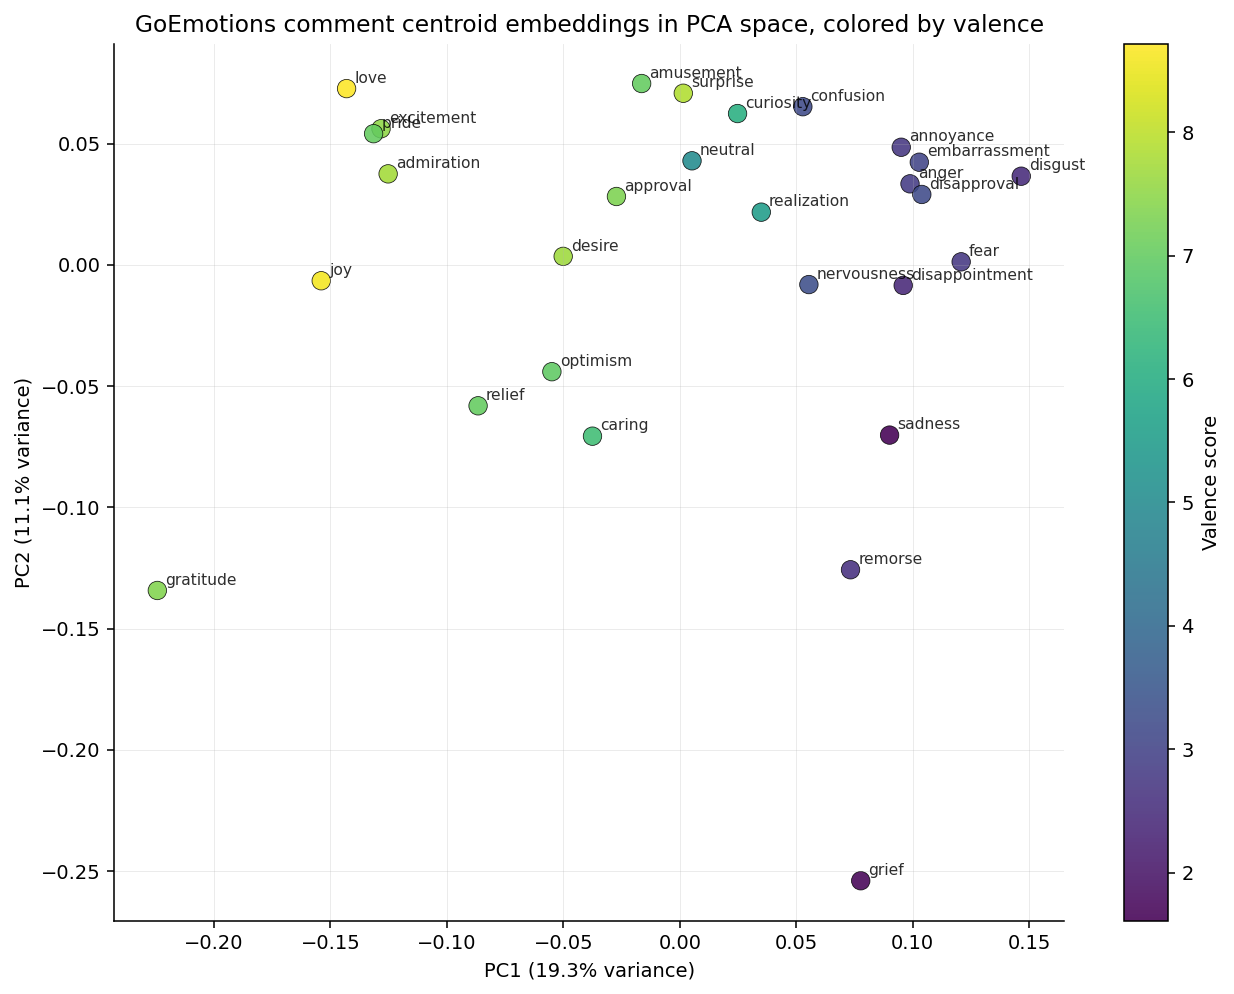

Saved: D:\pyprojects\m4r\new_plots\01_centroid_pca2_colored_by_arousal.png
Saved: D:\pyprojects\m4r\new_plots\01_centroid_pca2_colored_by_arousal.svg


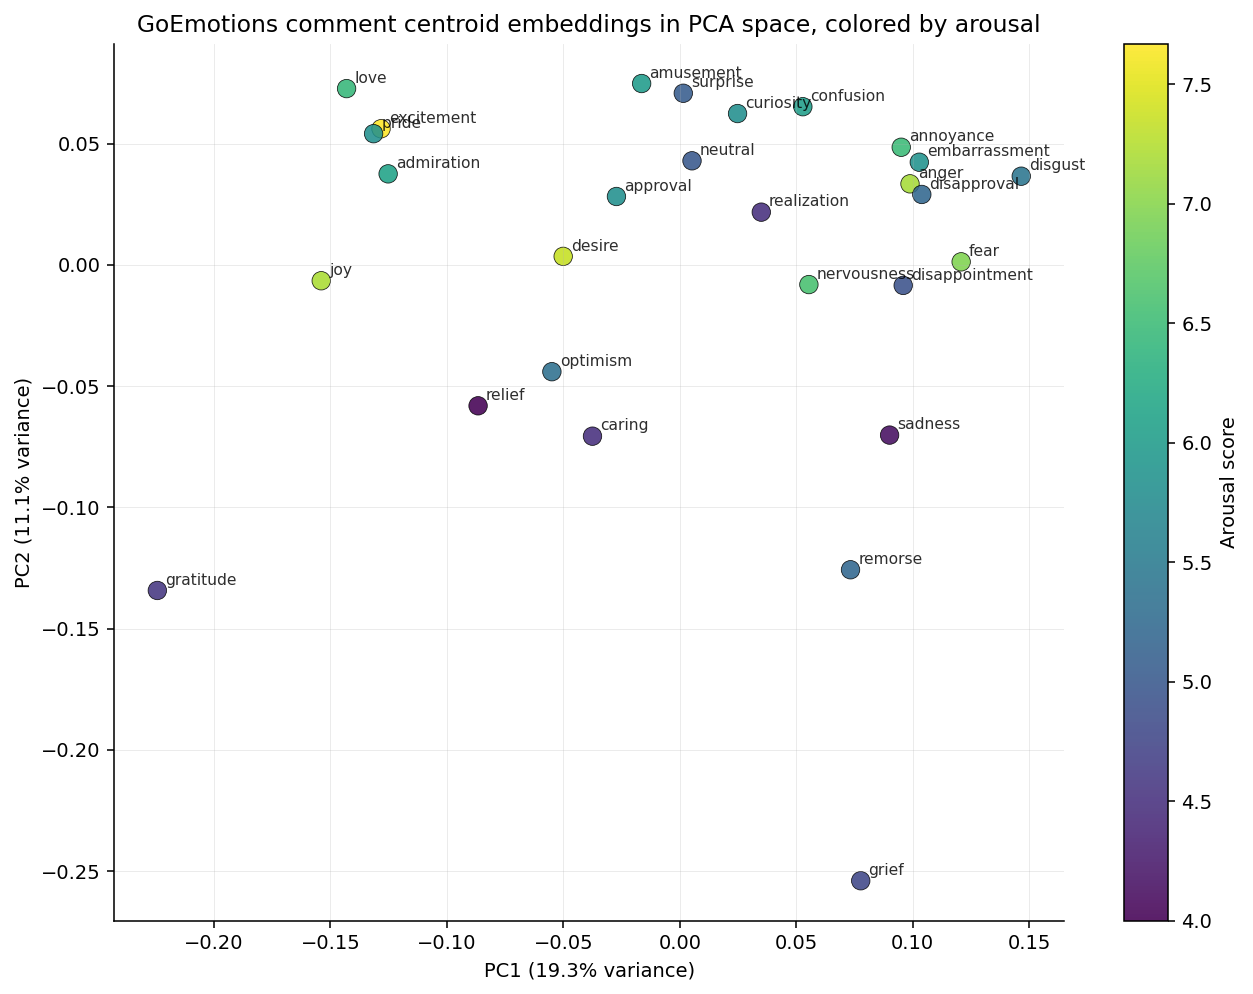

Saved: D:\pyprojects\m4r\new_plots\01_centroid_pca2_colored_by_dominance.png
Saved: D:\pyprojects\m4r\new_plots\01_centroid_pca2_colored_by_dominance.svg


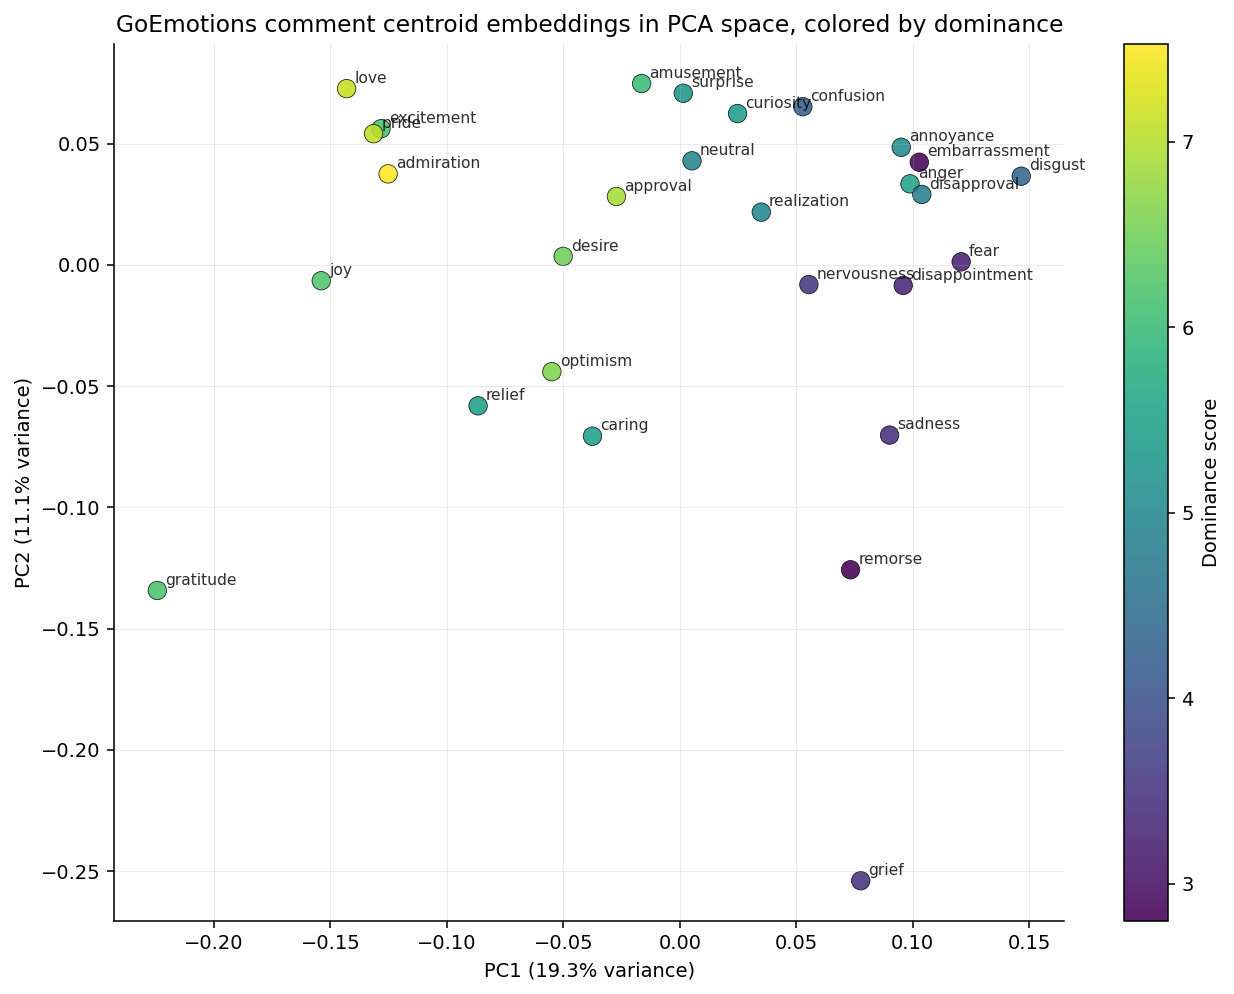

In [5]:
pca2 = PCA(n_components=2, random_state=SEED)
Z2_centroid = pca2.fit_transform(centroid_X)
explained = pca2.explained_variance_ratio_

for axis_name in ["valence", "arousal", "dominance"]:
    fig, ax = plt.subplots(figsize=(9.5, 7.2))
    sc = ax.scatter(
        Z2_centroid[:, 0],
        Z2_centroid[:, 1],
        c=centroid_meta[axis_name],
        s=90,
        alpha=0.88,
        edgecolor="black",
        linewidth=0.4,
    )

    for i, row in centroid_meta.reset_index(drop=True).iterrows():
        ax.annotate(
            row["label_name"],
            (Z2_centroid[i, 0], Z2_centroid[i, 1]),
            xytext=(4, 3),
            textcoords="offset points",
            fontsize=8,
            alpha=0.82,
        )

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f"{axis_name.capitalize()} score")
    ax.set_xlabel(f"PC1 ({explained[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({explained[1] * 100:.1f}% variance)")
    ax.set_title(f"GoEmotions comment centroid embeddings in PCA space, colored by {axis_name}")
    clean_axes(ax)
    fig.tight_layout()
    save_matplotlib(fig, f"01_centroid_pca2_colored_by_{axis_name}")
    plt.show()


## 2. Centroid cosine distance vs ground-truth affective distance

This cell always saves the valence-only plot requested for the paper. It also saves the configured ground-truth space from the configuration cell, so you can keep the full VAD diagnostic without playing notebook whack-a-mole.

Saved: D:\pyprojects\m4r\new_plots\02_centroid_cosine_vs_valence_pairs.csv
valence: Pearson r=0.446, Spearman rho=0.425, n=378
Saved: D:\pyprojects\m4r\new_plots\02_centroid_cosine_vs_valence_distance_scatter.png
Saved: D:\pyprojects\m4r\new_plots\02_centroid_cosine_vs_valence_distance_scatter.svg


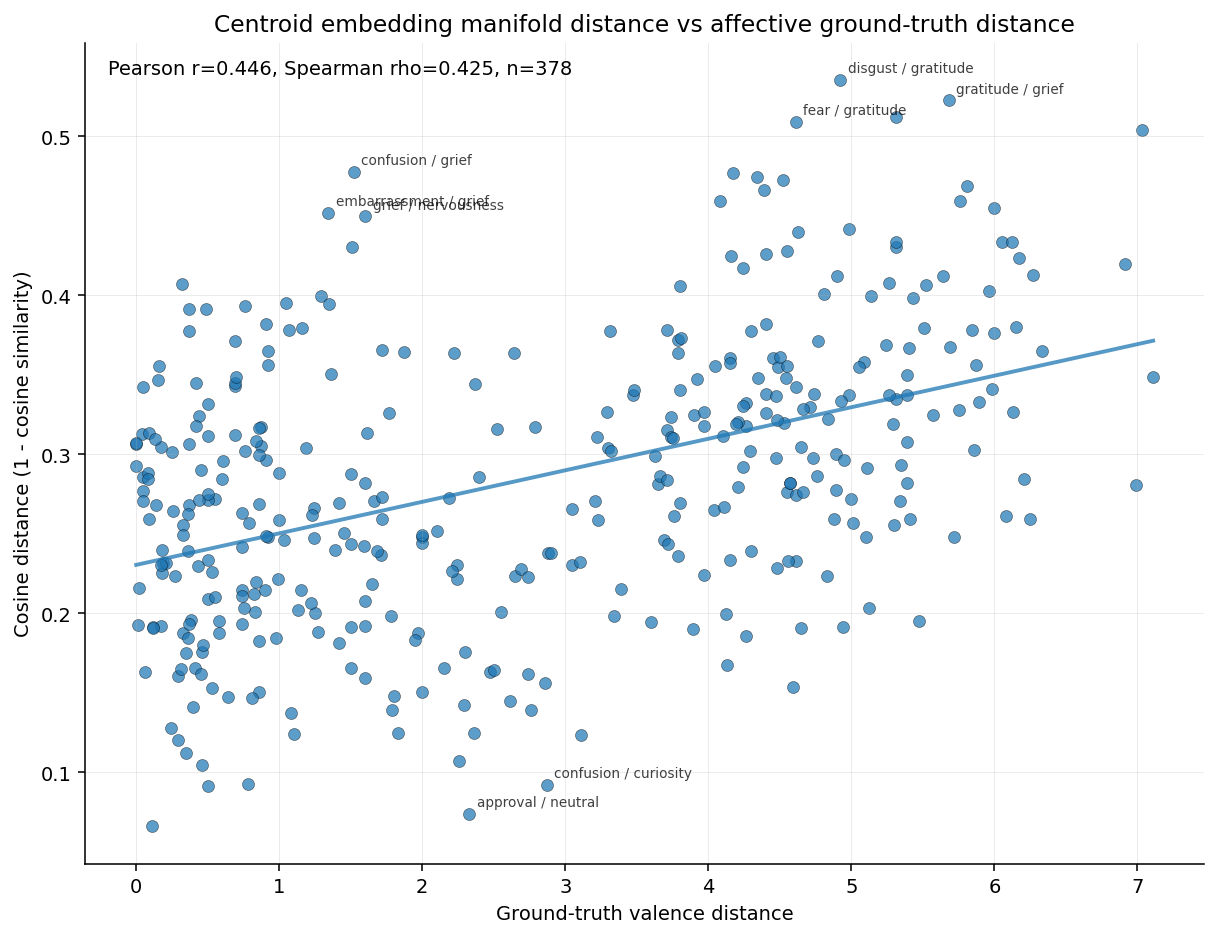

,label_i,label_j,manifold_distance,ground_truth_distance
245,disgust,gratitude,0.535506,4.92
300,gratitude,grief,0.522679,5.68
317,grief,pride,0.512197,5.31
287,fear,gratitude,0.509143,4.61
313,grief,love,0.504102,7.03
156,confusion,grief,0.477602,1.52
229,disapproval,gratitude,0.477218,4.17
260,embarrassment,gratitude,0.474310,4.34
65,anger,gratitude,0.472501,4.52
275,excitement,grief,0.468975,5.81


Saved: D:\pyprojects\m4r\new_plots\02_centroid_cosine_vs_vad_pairs.csv
VAD: Pearson r=0.472, Spearman rho=0.456, n=378
Saved: D:\pyprojects\m4r\new_plots\02_centroid_cosine_vs_vad_distance_scatter.png
Saved: D:\pyprojects\m4r\new_plots\02_centroid_cosine_vs_vad_distance_scatter.svg


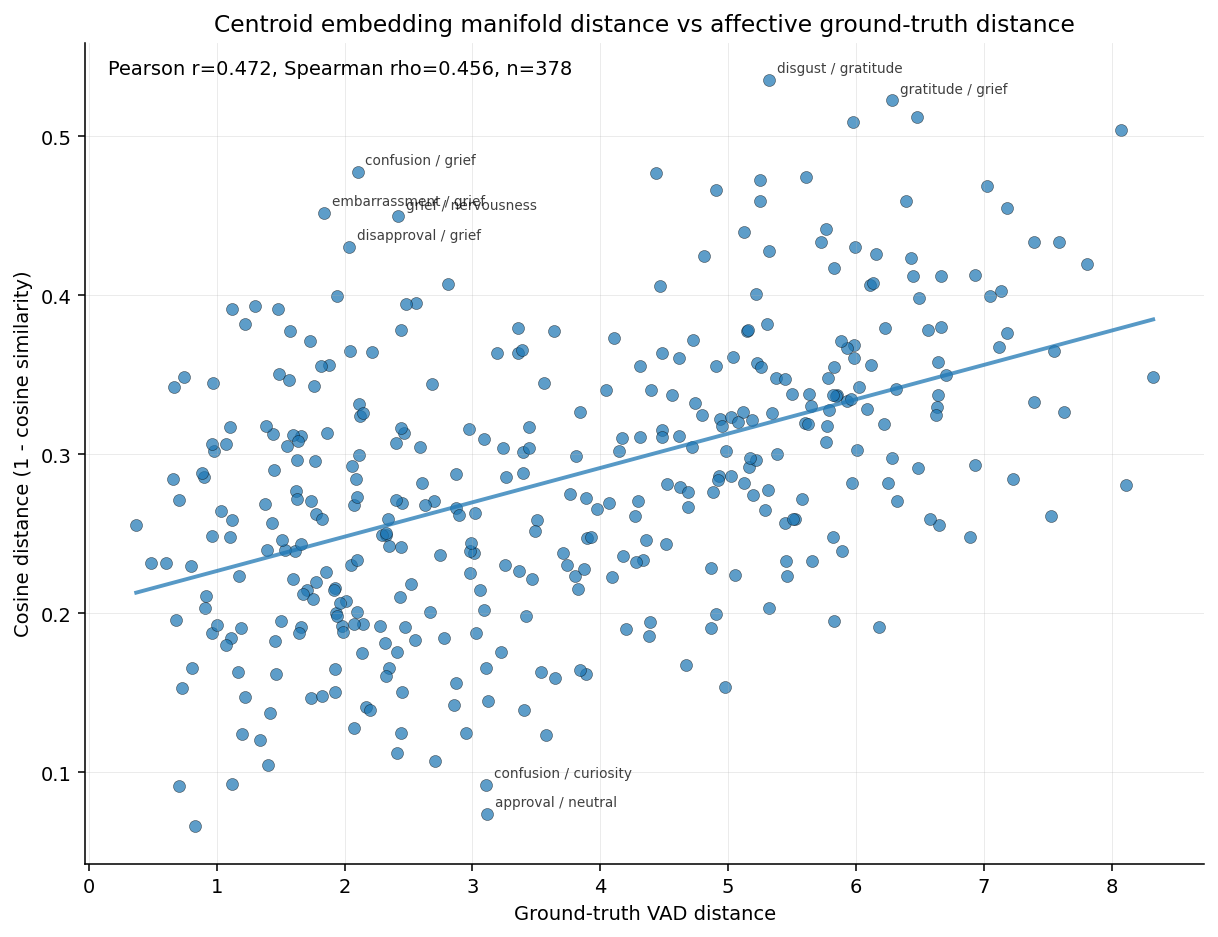

,label_i,label_j,manifold_distance,ground_truth_distance
245,disgust,gratitude,0.535506,5.319549
300,gratitude,grief,0.522679,6.283693
317,grief,pride,0.512197,6.478596
287,fear,gratitude,0.509143,5.973115
313,grief,love,0.504102,8.075184
156,confusion,grief,0.477602,2.102499
229,disapproval,gratitude,0.477218,4.435955
260,embarrassment,gratitude,0.474310,5.608547
65,anger,gratitude,0.472501,5.247418
275,excitement,grief,0.468975,7.020726


In [6]:
truth_spaces_to_plot = ["valence"]
if GROUND_TRUTH_SPACE not in truth_spaces_to_plot:
    truth_spaces_to_plot.append(GROUND_TRUTH_SPACE)

D_manifold, manifold_label = centroid_manifold_distance(centroid_X)

for truth_space in truth_spaces_to_plot:
    D_truth = vad_distance(centroid_vad, truth_space)

    pair_df = upper_triangle_frame(
        D_manifold,
        D_truth,
        labels=centroid_meta["label_name"].tolist(),
        x_name="manifold_distance",
        y_name="ground_truth_distance",
    )

    finite = np.isfinite(pair_df["manifold_distance"]) & np.isfinite(pair_df["ground_truth_distance"])
    plot_df = pair_df.loc[finite].copy()

    if len(plot_df) >= 3 and plot_df["manifold_distance"].std() > 0 and plot_df["ground_truth_distance"].std() > 0:
        pearson = pearsonr(plot_df["ground_truth_distance"], plot_df["manifold_distance"])
        spearman = spearmanr(plot_df["ground_truth_distance"], plot_df["manifold_distance"])
        title_stats = f"Pearson r={pearson.statistic:.3f}, Spearman rho={spearman.statistic:.3f}, n={len(plot_df)}"
    else:
        title_stats = f"Insufficient variation for correlation, n={len(plot_df)}"

    method_slug = DISTANCE_METHOD.lower().replace(" ", "_")
    truth_slug = truth_space.lower()
    csv_path = OUT_DIR / f"02_centroid_{method_slug}_vs_{truth_slug}_pairs.csv"
    pair_df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")
    print(f"{truth_space}: {title_stats}")

    fig, ax = plt.subplots(figsize=(8.8, 6.8))
    ax.scatter(
        plot_df["ground_truth_distance"],
        plot_df["manifold_distance"],
        s=38,
        alpha=0.72,
        edgecolor="black",
        linewidth=0.25,
    )

    # Add a simple least-squares trend line for visual orientation.
    if len(plot_df) >= 3 and plot_df["ground_truth_distance"].std() > 0:
        x = plot_df["ground_truth_distance"].to_numpy()
        y = plot_df["manifold_distance"].to_numpy()
        slope, intercept = np.polyfit(x, y, deg=1)
        xs = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, slope * xs + intercept, linewidth=2, alpha=0.75)

    # Label the most extreme residuals so suspicious pairs can be inspected.
    if len(plot_df) >= 8 and plot_df["ground_truth_distance"].std() > 0:
        x = plot_df["ground_truth_distance"].to_numpy()
        y = plot_df["manifold_distance"].to_numpy()
        slope, intercept = np.polyfit(x, y, deg=1)
        residual = np.abs(y - (slope * x + intercept))
        for idx in np.argsort(residual)[-8:]:
            row = plot_df.iloc[idx]
            ax.annotate(
                f"{row['label_i']} / {row['label_j']}",
                (row["ground_truth_distance"], row["manifold_distance"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=7,
                alpha=0.75,
            )

    ax.set_xlabel(f"Ground-truth {truth_space} distance")
    ax.set_ylabel(manifold_label)
    ax.set_title("Centroid embedding manifold distance vs affective ground-truth distance")
    ax.text(0.02, 0.98, title_stats, transform=ax.transAxes, va="top", ha="left", fontsize=10)
    clean_axes(ax)
    fig.tight_layout()
    save_matplotlib(fig, f"02_centroid_{method_slug}_vs_{truth_slug}_distance_scatter")
    plt.show()

    display(plot_df.sort_values("manifold_distance", ascending=False).head(10))


## 3. 3D Plotly PCA plot for fear, caring, gratitude, and love

This plots only comments with the chosen labels in the first three PCA dimensions. For each label it draws:

- comment points,
- a large mean marker,
- a semi-transparent 1-standard-deviation covariance ellipsoid as the variance summary.

The HTML version is always saved. Static PNG export is attempted, but Plotly needs `kaleido` installed for that.

In [10]:
def covariance_ellipsoid_surface(points: np.ndarray, n_std: float = 1.0, resolution: int = 28):
    """Return x, y, z surface grids for a covariance ellipsoid."""
    if len(points) < 4:
        return None
    center = points.mean(axis=0)
    cov = np.cov(points.T)
    if not np.all(np.isfinite(cov)):
        return None

    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.maximum(eigvals, 1e-12)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    radii = n_std * np.sqrt(eigvals)

    u = np.linspace(0, 2 * np.pi, resolution)
    v = np.linspace(0, np.pi, resolution)
    sphere = np.stack([
        np.outer(np.cos(u), np.sin(v)),
        np.outer(np.sin(u), np.sin(v)),
        np.outer(np.ones_like(u), np.cos(v)),
    ], axis=-1)

    ellipsoid = sphere @ np.diag(radii) @ eigvecs.T + center
    return ellipsoid[:, :, 0], ellipsoid[:, :, 1], ellipsoid[:, :, 2]


focus_meta = metadata[metadata["label_name"].isin(FOCUS_LABELS)].copy().reset_index(drop=False)
focus_meta = focus_meta.rename(columns={"index": "_row"})

if MAX_3D_PER_LABEL is not None:
    focus_meta = (
        focus_meta.groupby("label_name", group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), int(MAX_3D_PER_LABEL)), random_state=SEED))
        .reset_index(drop=True)
    )

if focus_meta.empty:
    raise ValueError(f"No comments found for labels: {FOCUS_LABELS}")

X_focus = X[focus_meta["_row"].to_numpy()]

if PCA_3D_FIT_SCOPE == "global":
    pca3 = PCA(n_components=3, random_state=SEED)
    pca3.fit(X)
    Z3 = pca3.transform(X_focus)
elif PCA_3D_FIT_SCOPE == "selected":
    pca3 = PCA(n_components=3, random_state=SEED)
    Z3 = pca3.fit_transform(X_focus)
else:
    raise ValueError("PCA_3D_FIT_SCOPE must be 'global' or 'selected'")

plot3d = focus_meta[["label_name", "text"]].copy() if "text" in focus_meta.columns else focus_meta[["label_name"]].copy()
plot3d["PC1"] = Z3[:, 0]
plot3d["PC2"] = Z3[:, 1]
plot3d["PC3"] = Z3[:, 2]

label_order = [label for label in FOCUS_LABELS if label in set(plot3d["label_name"])]
colors = px.colors.qualitative.Safe + px.colors.qualitative.Dark24
color_map = {label: colors[i % len(colors)] for i, label in enumerate(label_order)}

fig = go.Figure()

for label in label_order:
    df_lab = plot3d[plot3d["label_name"] == label]
    hover_text = df_lab["text"] if "text" in df_lab.columns else [label] * len(df_lab)

    fig.add_trace(go.Scatter3d(
        x=df_lab["PC1"],
        y=df_lab["PC2"],
        z=df_lab["PC3"],
        mode="markers",
        name=f"{label} comments (n={len(df_lab)})",
        marker=dict(size=3.2, opacity=1, color=color_map[label]),
        text=hover_text,
        hovertemplate=(
            f"label={label}<br>"
            "PC1=%{x:.3f}<br>PC2=%{y:.3f}<br>PC3=%{z:.3f}<br>"
            "%{text}<extra></extra>"
        ),
    ))

    pts = df_lab[["PC1", "PC2", "PC3"]].to_numpy()
    mean = pts.mean(axis=0)
    var = pts.var(axis=0, ddof=1) if len(pts) > 1 else np.zeros(3)

    fig.add_trace(go.Scatter3d(
        x=[mean[0]],
        y=[mean[1]],
        z=[mean[2]],
        mode="markers+text",
        name=f"{label} mean",
        marker=dict(size=9, symbol="diamond", color=color_map[label], line=dict(width=2, color="black")),
        text=[f"{label}<br>mean<br>var=({var[0]:.2g}, {var[1]:.2g}, {var[2]:.2g})"],
        textposition="top center",
        hovertemplate=(
            f"{label} mean<br>"
            "PC1=%{x:.3f}<br>PC2=%{y:.3f}<br>PC3=%{z:.3f}<br>"
            f"variance PC1={var[0]:.4g}<br>variance PC2={var[1]:.4g}<br>variance PC3={var[2]:.4g}"
            "<extra></extra>"
        ),
    ))

    surface = covariance_ellipsoid_surface(pts, n_std=1.0, resolution=26)
    if surface is not None:
        ex, ey, ez = surface
        fig.add_trace(go.Surface(
            x=ex,
            y=ey,
            z=ez,
            name=f"{label} 1-sigma ellipsoid",
            showscale=False,
            opacity=0.16,
            surfacecolor=np.zeros_like(ex),
            colorscale=[[0, color_map[label]], [1, color_map[label]]],
            hoverinfo="skip",
        ))

explained3 = pca3.explained_variance_ratio_
fig.update_layout(
    title=(
        "Selected GoEmotions comments in first three PCA dimensions "
        f"({PCA_3D_FIT_SCOPE} PCA fit)"
    ),
    scene=dict(
        xaxis_title=f"PC1 ({explained3[0] * 100:.1f}% var.)",
        yaxis_title=f"PC2 ({explained3[1] * 100:.1f}% var.)",
        zaxis_title=f"PC3 ({explained3[2] * 100:.1f}% var.)",
    ),
    legend=dict(itemsizing="constant"),
    width=1050,
    height=780,
    margin=dict(l=0, r=0, t=60, b=0),
)

html_path = OUT_DIR / "03_selected_labels_pca3_mean_variance.html"
fig.write_html(html_path)
print(f"Saved: {html_path}")

# Static export is nice for reports, but Plotly needs kaleido installed.
png_path = OUT_DIR / "03_selected_labels_pca3_mean_variance.png"
try:
    fig.write_image(png_path, scale=2)
    print(f"Saved: {png_path}")
except Exception as exc:
    print("Static PNG export skipped. Install kaleido with `pip install -U kaleido` if you need it.")
    print(f"Plotly image export error: {exc}")

fig.show()

Saved: D:\pyprojects\m4r\new_plots\03_selected_labels_pca3_mean_variance.html
Static PNG export skipped. Install kaleido with `pip install -U kaleido` if you need it.
Plotly image export error: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



## Optional: save a compact summary table

In [8]:
summary_rows = []
for label in sorted(metadata["label_name"].unique()):
    n = int((metadata["label_name"] == label).sum())
    vad_row = vad_df[vad_df["label_name"] == label]
    if vad_row.empty:
        continue
    summary_rows.append({
        "label_name": label,
        "n_comments": n,
        "valence": float(vad_row["valence"].iloc[0]),
        "arousal": float(vad_row["arousal"].iloc[0]),
        "dominance": float(vad_row["dominance"].iloc[0]),
    })
summary = pd.DataFrame(summary_rows).sort_values("label_name")
summary_path = OUT_DIR / "goemotions_label_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}")
display(summary)

Saved: D:\pyprojects\m4r\new_plots\goemotions_label_summary.csv


,label_name,n_comments,valence,arousal,dominance
0,admiration,201,7.74,6.11,7.53
1,amusement,201,7.00,6.00,6.00
2,anger,201,2.85,7.17,5.55
3,annoyance,201,2.74,6.49,5.09
4,approval,201,7.33,5.83,6.89
5,caring,201,6.50,4.50,5.50
6,confusion,201,3.21,6.03,4.24
7,curiosity,201,6.08,5.82,5.42
8,desire,201,7.69,7.35,6.49
9,disappointment,201,2.39,4.92,3.29
